In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
pd.set_option("display.max_columns", None)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.linear_model import LinearRegression, Ridge
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, make_scorer
from lime.lime_tabular import LimeTabularExplainer
import pickle

In [ ]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Documents\csv files\train (2).csv")

In [3]:
df.shape

(1460, 81)

## Data Cleaning

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.isna().sum().sort_values(ascending = False) #checking for null values

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [6]:
missing_perc = df.isna().mean() * 100 #percentage of missing values

missing_perc[missing_perc > 0] #columns with null values

LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64

In [7]:
cols_to_drop = missing_perc[missing_perc > 30]

cols_to_drop.index

Index(['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [8]:
df.drop(columns = cols_to_drop.index, inplace = True)

In [9]:
missing_perc = df.isna().mean() * 100 

missing_perc[missing_perc > 0] 

LotFrontage     17.739726
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
dtype: float64

## Log Transformation

In [10]:
y = np.log1p(df["SalePrice"])
y

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

## Exploratory Data Analysis

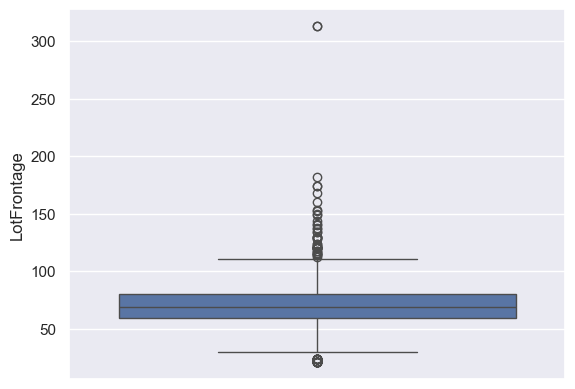

In [11]:
sns.boxplot(df["LotFrontage"]) #to check if there are outliers
plt.show()

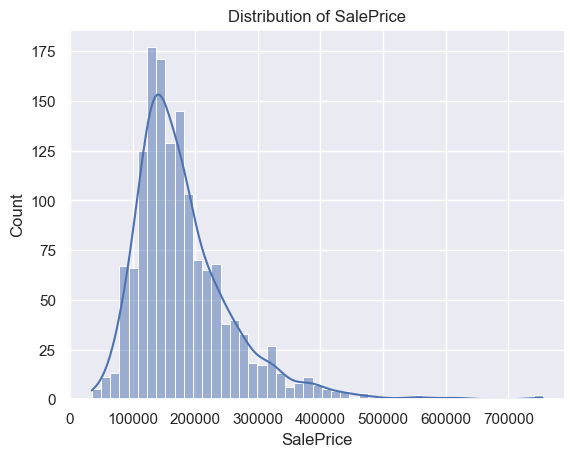

In [79]:
sns.histplot(df["SalePrice"], kde = True)
plt.title("Distribution of SalePrice")
plt.show()

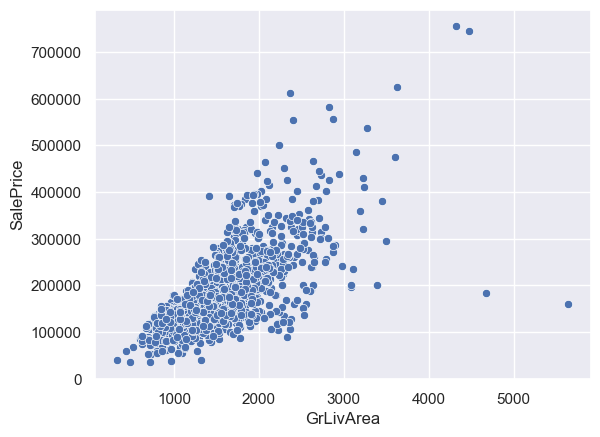

In [81]:
sns.scatterplot(x = df["GrLivArea"], y = df["SalePrice"])
plt.show()

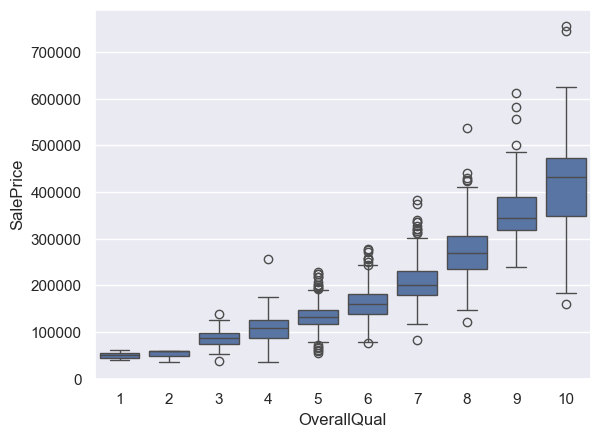

In [14]:
sns.boxplot(x = df["OverallQual"], y = df["SalePrice"])
plt.show()

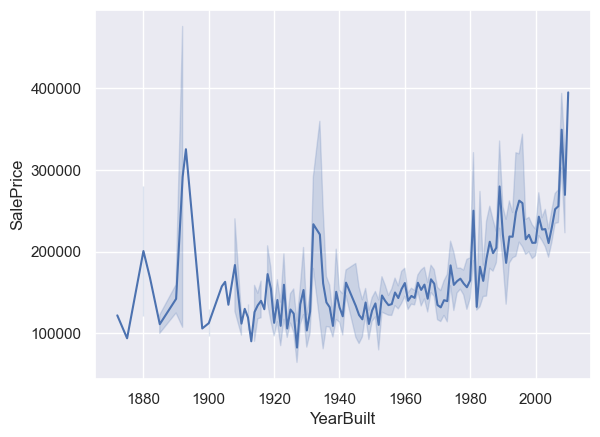

In [15]:
sns.lineplot(x = df["YearBuilt"], y = df["SalePrice"])
plt.show()

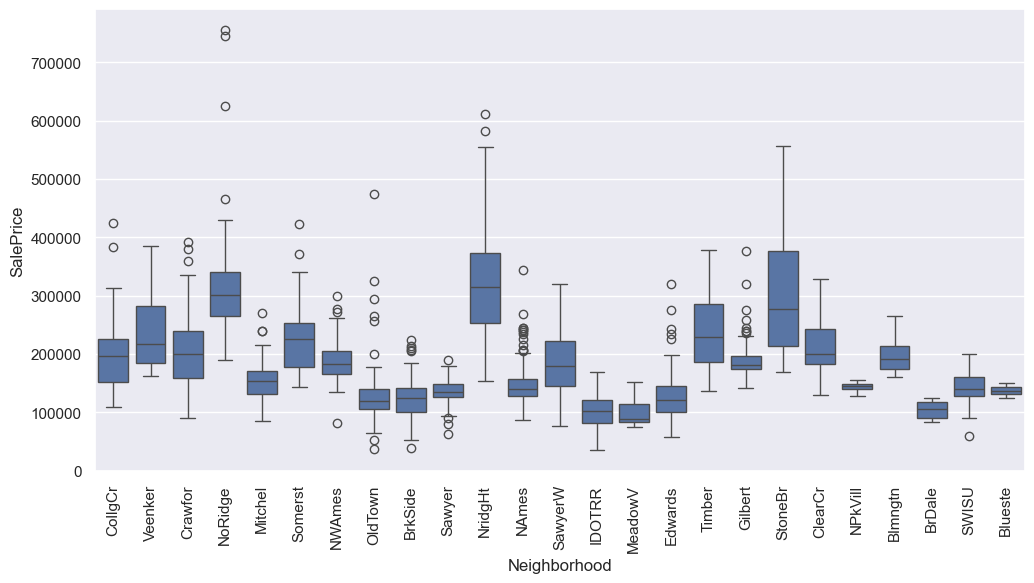

In [16]:
plt.figure(figsize = (12, 6))
sns.boxplot(x = df["Neighborhood"], y = df["SalePrice"])
plt.xticks(rotation = 90)
plt.show()

In [17]:
numerical_cols = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
numerical_cols

['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [18]:
#filling the numerical columns with the median because median is not affected by outliers
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

In [19]:
categorical_cols = df.select_dtypes(include = ["object"]).columns.tolist()
categorical_cols

['MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'SaleType',
 'SaleCondition']

In [20]:
#filling the categorical columns with the mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

## Feature Encoding

In [22]:
df.shape #amount of rows and columns after cleaning

(1460, 75)

In [23]:
X = df.drop(columns = ["SalePrice", "Id"]) #independent variable

y #dependent variable which is the transformed value

0       12.247699
1       12.109016
2       12.317171
3       11.849405
4       12.429220
          ...    
1455    12.072547
1456    12.254868
1457    12.493133
1458    11.864469
1459    11.901590
Name: SalePrice, Length: 1460, dtype: float64

## Label Encoding

In [24]:
for col in categorical_cols:
    le = LabelEncoder() 
    X[col] = le.fit_transform(X[col]) #transform each categorical column

In [25]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,1,12,13,196.0,2,4,2,2,3,3,2,706,5,0,150,856,1,0,1,4,856,854,0,1710,1,0,2,1,3,1,2,8,6,0,1,2003.0,1,2,548,4,4,2,0,61,0,0,0,0,0,2,2008,8,4
1,20,3,80.0,9600,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,1,8,8,0.0,3,4,1,2,3,1,0,978,5,0,284,1262,1,0,1,4,1262,0,0,1262,0,1,2,0,3,1,3,6,6,1,1,1976.0,1,2,460,4,4,2,298,0,0,0,0,0,0,5,2007,8,4
2,60,3,68.0,11250,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,1,12,13,162.0,2,4,2,2,3,2,2,486,5,0,434,920,1,0,1,4,920,866,0,1786,1,0,2,1,3,1,2,6,6,1,1,2001.0,1,2,608,4,4,2,0,42,0,0,0,0,0,9,2008,8,4
3,70,3,60.0,9550,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,1,13,15,0.0,3,4,0,3,1,3,0,216,5,0,540,756,1,2,1,4,961,756,0,1717,1,0,1,0,3,1,2,7,6,1,5,1998.0,2,3,642,4,4,2,0,35,272,0,0,0,0,2,2006,8,0
4,60,3,84.0,14260,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,1,12,13,350.0,2,4,2,2,3,0,2,655,5,0,490,1145,1,0,1,4,1145,1053,0,2198,1,0,2,1,4,1,2,9,6,1,1,2000.0,1,3,836,4,4,2,192,84,0,0,0,0,0,12,2008,8,4


In [26]:
X.shape

(1460, 73)

## Feature Scaling

In [27]:
scaler = StandardScaler()

scaledX = scaler.fit_transform(X)

In [28]:
#Standard Scaler Mean = 0, Std = 1,
scaledX

array([[ 0.07337496, -0.04553194, -0.22087509, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.46031974, ..., -0.61443862,
         0.31386709,  0.2085023 ],
       [ 0.07337496, -0.04553194, -0.08463612, ...,  0.13877749,
         0.31386709,  0.2085023 ],
       ...,
       [ 0.30985939, -0.04553194, -0.1754621 , ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194, -0.08463612, ...,  1.64520971,
         0.31386709,  0.2085023 ],
       [-0.87256276, -0.04553194,  0.23325479, ...,  0.13877749,
         0.31386709,  0.2085023 ]])

## Train Test Split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(scaledX, y, test_size = 0.2, random_state = 42)

In [64]:
X_train.shape #80%

(1168, 73)

In [31]:
X_test.shape #20%

(292, 73)

## Model Training

In [72]:
#LGB
lgb = LGBMRegressor(random_state = 42)
#Catboost
cat = CatBoostRegressor(random_state = 42, verbose = 0)
#Ridge
ridge = Ridge()
#Linear Reg
lin = LinearRegression()
#Random Forest
rand = RandomForestRegressor(random_state = 42)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3145
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 68
[LightGBM] [Info] Start training from score 12.030658


LGBMRegressor(random_state=42)

In [82]:
#fit the models to the training set
lgb.fit(X_train, y_train)
cat.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lin.fit(X_train, y_train)
rand.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3145
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 68
[LightGBM] [Info] Start training from score 12.030658


RandomForestRegressor(random_state=42)

In [73]:
lgb_pred = lgb.predict(X_test)
cat_pred = cat.predict(X_test)
ridge_pred = ridge.predict(X_test)
lin_pred = lin.predict(X_test)
rand_pred = rand.predict(X_test)

C:\Users\USER\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [83]:
cat.get_params()

{'loss_function': 'RMSE', 'verbose': 0, 'random_state': 42}

## Model Evaluation

In [44]:
def evaluation_metrics(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)

    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mse = mean_squared_error(y_true_orig, y_pred_orig)
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    mape = np.mean(np.abs((y_true_orig - y_pred_orig)/ y_true_orig)) * 100
    r2 = r2_score(y_true_orig, y_pred_orig)

    print(f"RMSE : {rmse:,.2f}")
    print(f"MSE : {mse:,.2f}")
    print(f"MAE : {mae:,.2f}")
    print(f"MAPE : {mape:,.2f}%")
    print(f"R2 : {r2:,.4f}")

In [76]:
print("=== LGBM Regressor ===")
evaluation_metrics(y_test, lgb_pred)

=== LGBM Regressor ===
RMSE : 29,393.89
MSE : 864,000,956.87
MAE : 16,474.49
MAPE : 9.46%
R2 : 0.8874


In [77]:
print("=== CatBoost ===")
evaluation_metrics(y_test, cat_pred)

=== CatBoost ===
RMSE : 27,713.23
MSE : 768,023,252.69
MAE : 15,579.47
MAPE : 8.97%
R2 : 0.8999


In [47]:
print("=== Ridge ===")
evaluation_metrics(y_test, ridge_pred)

=== Ridge ===
RMSE : 27,568.80
MSE : 760,038,936.50
MAE : 18,123.40
MAPE : 11.08%
R2 : 0.9009


In [48]:
print("=== XGB ===")
evaluation_metrics(y_test, xgb_pred)

=== XGB ===
RMSE : 26,198.81
MSE : 686,377,690.20
MAE : 16,689.29
MAPE : 10.45%
R2 : 0.9105


In [49]:
print("=== Linear Regression ===")
evaluation_metrics(y_test, lin_pred)

=== Linear Regression ===
RMSE : 27,575.10
MSE : 760,386,367.41
MAE : 18,127.31
MAPE : 11.08%
R2 : 0.9009


In [50]:
print("=== Random Forest ===")
evaluation_metrics(y_test, rand_pred)

=== Random Forest ===
RMSE : 28,591.45
MSE : 817,470,806.92
MAE : 17,234.08
MAPE : 10.13%
R2 : 0.8934


## Cross Validation

In [51]:
def rmse(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    
def mae(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return mean_absolute_error(y_true_orig, y_pred_orig)
    
def mape(y_true_log, y_pred_log):
    y_true_orig = np.expm1(y_true_log)
    y_pred_orig = np.expm1(y_pred_log)
    return np.mean(np.abs((y_true_orig - y_pred_orig)/ y_true_orig)) * 100

#creating scorers
scoring = {'RMSE' : make_scorer(rmse, greater_is_better = False),
           'MAE' : make_scorer(mae, greater_is_better = False),
           'MAPE' : make_scorer(mape, greater_is_better = False),
          'r2' : 'r2'}

In [52]:
cv_results = cross_validate(lgb, X_train, y_train, scoring = scoring, cv = 5, n_jobs = -1, return_train_score = False)

print("=== LightGBM CV Results ===")
print(f"RMSE : { -cv_results['test_RMSE'].mean():,.2f} (+/- {cv_results['test_RMSE'].std():.2f})")
print(f"MAE : { -cv_results['test_MAE'].mean():,.2f} (+/- {cv_results['test_MAE'].std():.2f})")
print(f"MAPE : { -cv_results['test_MAPE'].mean():,.2f}% (+/- {cv_results['test_MAPE'].std():.2f})")
print(f"R2 : { cv_results['test_r2'].mean():.4f}")

=== LightGBM CV Results ===
RMSE : 28,515.93 (+/- 4588.75)
MAE : 16,618.51 (+/- 1837.10)
MAPE : 9.34% (+/- 1.15)
R2 : 0.8810


In [53]:
cv_results = cross_validate(cat, X_train, y_train, scoring = scoring, cv = 5, n_jobs = -1, return_train_score = False)

print("=== CatBoost CV Results ===")
print(f"RMSE : { -cv_results['test_RMSE'].mean():,.2f} (+/- {cv_results['test_RMSE'].std():.2f})")
print(f"MAE : { -cv_results['test_MAE'].mean():,.2f} (+/- {cv_results['test_MAE'].std():.2f})")
print(f"MAPE : { -cv_results['test_MAPE'].mean():,.2f}% (+/- {cv_results['test_MAPE'].std():.2f})")
print(f"R2 : { cv_results['test_r2'].mean():.4f}")

=== CatBoost CV Results ===
RMSE : 27,362.96 (+/- 4060.81)
MAE : 14,951.15 (+/- 1068.74)
MAPE : 8.45% (+/- 0.75)
R2 : 0.8972


In [54]:
cv_results = cross_validate(ridge, X_train, y_train, scoring = scoring, cv = 5, n_jobs = -1, return_train_score = False)

print("=== Ridge CV Results ===")
print(f"RMSE : { -cv_results['test_RMSE'].mean():,.2f} (+/- {cv_results['test_RMSE'].std():.2f})")
print(f"MAE : { -cv_results['test_MAE'].mean():,.2f} (+/- {cv_results['test_MAE'].std():.2f})")
print(f"MAPE : { -cv_results['test_MAPE'].mean():,.2f}% (+/- {cv_results['test_MAPE'].std():.2f})")
print(f"R2 : { cv_results['test_r2'].mean():.4f}")

=== Ridge CV Results ===
RMSE : 48,190.26 (+/- 33217.69)
MAE : 19,141.39 (+/- 2860.09)
MAPE : 10.94% (+/- 2.04)
R2 : 0.8397


In [55]:
cv_results = cross_validate(lin, X_train, y_train, scoring = scoring, cv = 5, n_jobs = -1, return_train_score = False)

print("=== Linear Regression CV Results ===")
print(f"RMSE : { -cv_results['test_RMSE'].mean():,.2f} (+/- {cv_results['test_RMSE'].std():.2f})")
print(f"MAE : { -cv_results['test_MAE'].mean():,.2f} (+/- {cv_results['test_MAE'].std():.2f})")
print(f"MAPE : { -cv_results['test_MAPE'].mean():,.2f}% (+/- {cv_results['test_MAPE'].std():.2f})")
print(f"R2 : { cv_results['test_r2'].mean():.4f}")

=== Linear Regression CV Results ===
RMSE : 48,224.76 (+/- 33247.40)
MAE : 19,150.14 (+/- 2862.16)
MAPE : 10.95% (+/- 2.04)
R2 : 0.8395


In [56]:
cv_results = cross_validate(rand, X_train, y_train, scoring = scoring, cv = 5, n_jobs = -1, return_train_score = False)

print("=== Random Forest CV Results ===")
print(f"RMSE : { -cv_results['test_RMSE'].mean():,.2f} (+/- {cv_results['test_RMSE'].std():.2f})")
print(f"MAE : { -cv_results['test_MAE'].mean():,.2f} (+/- {cv_results['test_MAE'].std():.2f})")
print(f"MAPE : { -cv_results['test_MAPE'].mean():,.2f}% (+/- {cv_results['test_MAPE'].std():.2f})")
print(f"R2 : { cv_results['test_r2'].mean():.4f}")

=== Random Forest CV Results ===
RMSE : 30,097.29 (+/- 4221.33)
MAE : 17,775.37 (+/- 2108.70)
MAPE : 10.04% (+/- 1.48)
R2 : 0.8638


## Feature Importance

In [57]:
importance = cat.feature_importances_

importance

array([5.31208467e-01, 5.45210221e-01, 5.48989478e-01, 3.69371508e+00,
       0.00000000e+00, 7.06083829e-01, 5.31425774e-01, 1.28773242e-04,
       1.26719109e-01, 6.78871394e-02, 1.37257703e+00, 5.51344224e-01,
       1.37113859e-02, 1.58478623e-01, 1.32981394e-01, 1.89991989e+01,
       2.86528983e+00, 4.67133010e+00, 1.84949035e+00, 2.49877557e-01,
       3.59986177e-02, 4.82391347e-01, 2.24007597e-01, 4.73297766e-01,
       1.31762639e+00, 8.56390531e-02, 1.15701306e-01, 1.38927177e+00,
       2.75232539e-01, 6.53168527e-01, 1.03403193e+00, 3.04310226e+00,
       1.40800490e-02, 1.87447807e-01, 6.20664050e-01, 4.02246999e+00,
       1.47833565e-02, 5.62317474e-01, 2.40377524e+00, 2.28735453e-02,
       3.23724350e+00, 6.99930134e-01, 4.08573931e-04, 1.63691991e+01,
       3.38923735e-01, 4.37631848e-03, 7.84877709e-01, 5.51487421e-01,
       3.37660493e-01, 2.39012338e-01, 1.84655536e+00, 5.88572822e-01,
       5.85989122e-01, 3.27566753e+00, 8.03322009e-01, 1.43474931e+00,
      

In [58]:
features = X.columns

In [59]:
feat_imp = pd.Series(importance, index = features).sort_values()
feat_imp

Street           0.000000
Utilities        0.000129
LowQualFinSF     0.000409
BsmtHalfBath     0.004376
Condition2       0.013711
                  ...    
GarageArea       3.748892
TotalBsmtSF      4.022470
YearBuilt        4.671330
GrLivArea       16.369199
OverallQual     18.999199
Length: 73, dtype: float64

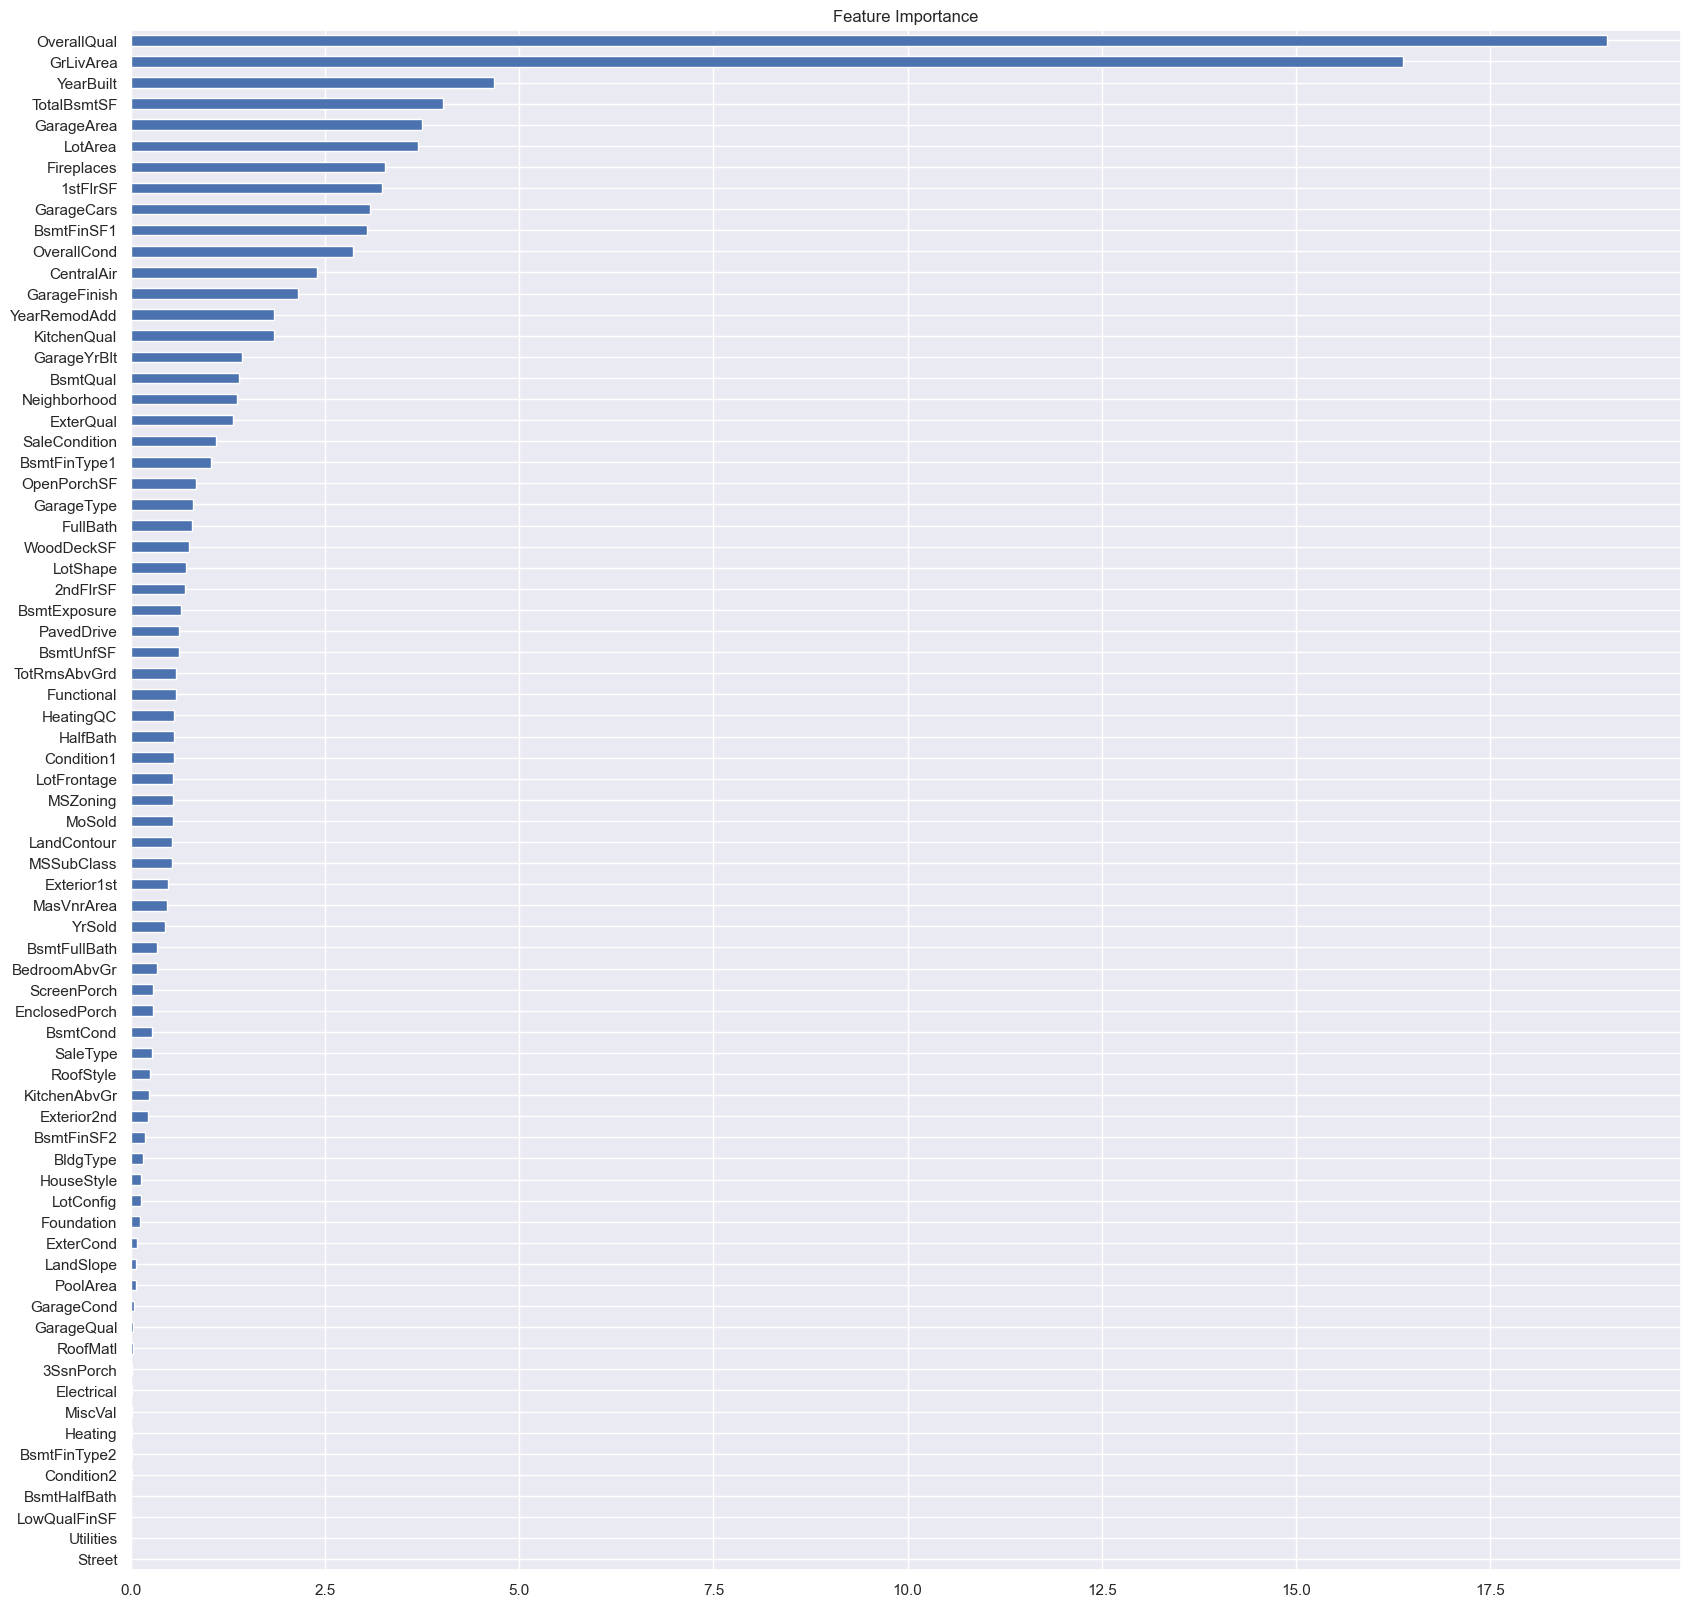

In [60]:
feat_imp.plot(kind = 'barh', figsize = (20,20))
plt.title("Feature Importance")
plt.show()

In [89]:
feature_names = X.columns

## LIME

In [90]:
explainer = LimeTabularExplainer(
    training_data = X_train,
    feature_names = feature_names,
    mode = 'regression')

In [92]:
exp = explainer.explain_instance(X_test[0], cat.predict)

In [93]:
exp.show_in_notebook()

## Model Preservation

In [94]:
#model
with open("cat_model.pkl", "wb") as file:
    pickle.dump(cat, file)

In [95]:
#encoder
with open("cat_encoder.pkl", "wb") as file:
    pickle.dump(le, file)

#scaler
with open("cat_scaler.pkl", "wb") as file:
    pickle.dump(scaler, file)